# Data Roles Salary Analysis

Salary analysis for the data-analyst-adjacent role family (Data Analyst, Data Scientist, Data Engineer, ML Engineer, Analytics Engineer).

**Source.** [ai-jobs.net](https://ai-jobs.net/salaries/) `salaries.csv`, accessed via the [foorilla/ai-jobs-net-salaries](https://github.com/foorilla/ai-jobs-net-salaries) GitHub mirror. ~151K postings spanning 2020-2025, of which ~54K map to a data role after taxonomy filtering and per-role 5th/95th-percentile outlier trim. The pipeline lives in `aijobs_net.py`.

**What each row is.** A single job posting. The salary figure is base salary only (no equity), expressed in USD (`salary_in_usd`). The dataset is global — US is ~70% of postings, then CA / GB / AU / DE.

**Caveats worth keeping in mind.**
- Sample is heavily back-loaded: 2020-2021 have only ~300 rows combined. Trend charts gate to year/role cells with n≥30.
- ~60% of postings are tagged Senior — this reflects who lists on ai-jobs.net, not the actual labor market.
- `company_size` is 98% M and `employment_type` is 99.5% FT, so they're effectively constants — not modelled here.
- `remote_ratio` is essentially binary (0 = on-site, 100 = fully remote); the partial-remote bucket has 113 rows total.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import aijobs_net

sns.set_theme(style='whitegrid', context='notebook')
ROLES = ['Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer', 'Analytics Engineer']
PALETTE = dict(zip(ROLES, sns.color_palette('Set2', n_colors=len(ROLES))))

df = aijobs_net.build()
print(f'rows: {len(df):,}   year range: {df["year"].min()} → {df["year"].max()}')
df['role'].value_counts().reindex(ROLES)

rows: 54,168   year range: 2020 → 2025


role
Data Analyst          12496
Data Scientist        16926
Data Engineer         14788
ML Engineer            8029
Analytics Engineer     1929
Name: count, dtype: int64

## 1. Postings per year, by role

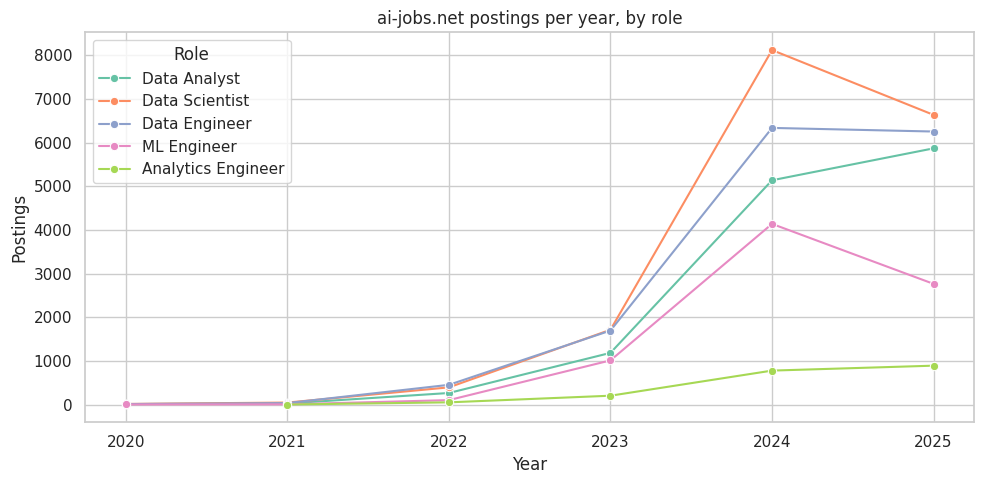

In [2]:
counts = df.groupby(['year', 'role']).size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(counts, x='year', y='n', hue='role', hue_order=ROLES,
             palette=PALETTE, marker='o', ax=ax)
ax.set_title('ai-jobs.net postings per year, by role')
ax.set_xlabel('Year'); ax.set_ylabel('Postings')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

## 2. Median base salary by year

Year/role cells with fewer than 30 postings are dropped so the line doesn't twitch on noise.

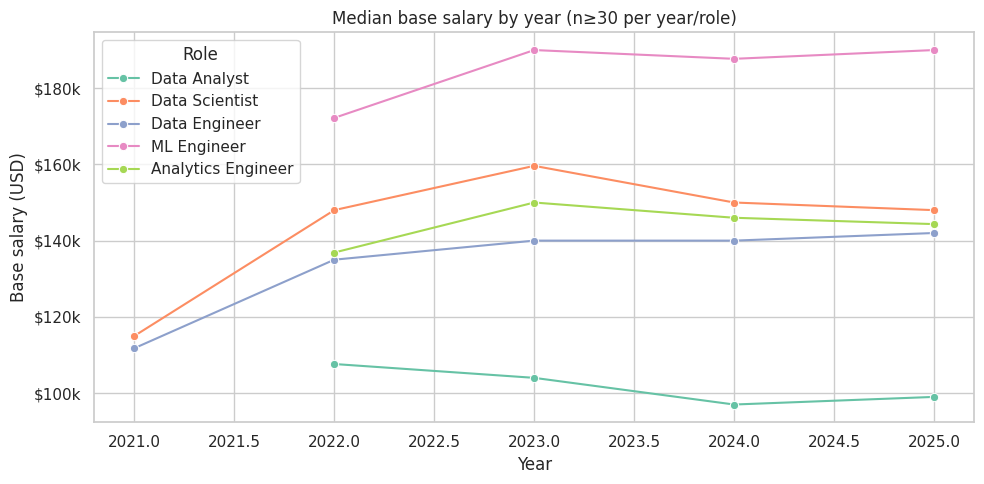

In [3]:
n = df.groupby(['year', 'role']).size().reset_index(name='n')
trend = df.groupby(['year', 'role'])['salary_in_usd'].median().reset_index()
trend = trend.merge(n).query('n >= 30')

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(trend, x='year', y='salary_in_usd', hue='role',
             hue_order=ROLES, palette=PALETTE, marker='o', ax=ax)
ax.set_title('Median base salary by year (n≥30 per year/role)')
ax.set_xlabel('Year'); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

## 3. Distribution by role (2024-2025)

Recent two years where each role has thousands of observations.

/tmp/ipykernel_2116/1589356270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(recent, x='role', y='salary_in_usd', order=ROLES,


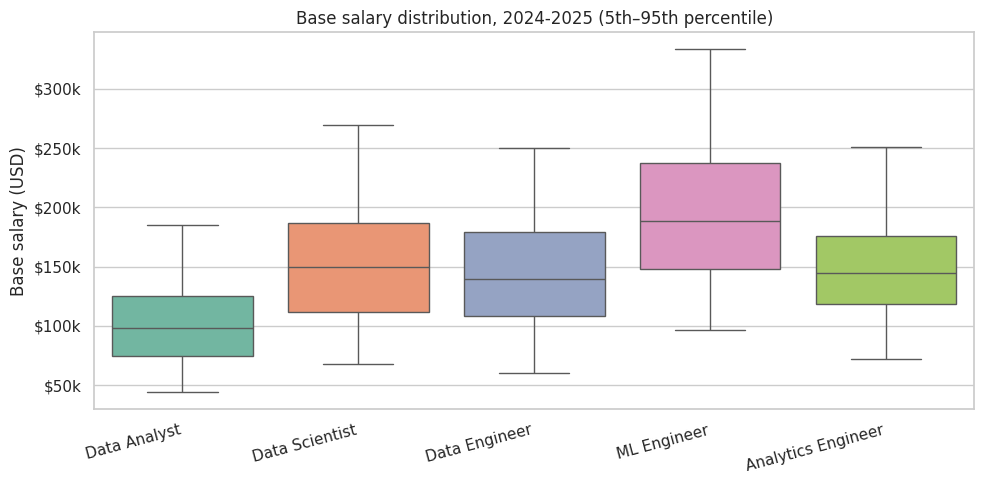

In [4]:
recent = df[df['year'].isin([2024, 2025])]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(recent, x='role', y='salary_in_usd', order=ROLES,
            palette=PALETTE, ax=ax)
ax.set_title('Base salary distribution, 2024-2025 (5th–95th percentile)')
ax.set_xlabel(''); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right'); plt.tight_layout()

## 4. Salary by experience level (2024-2025)

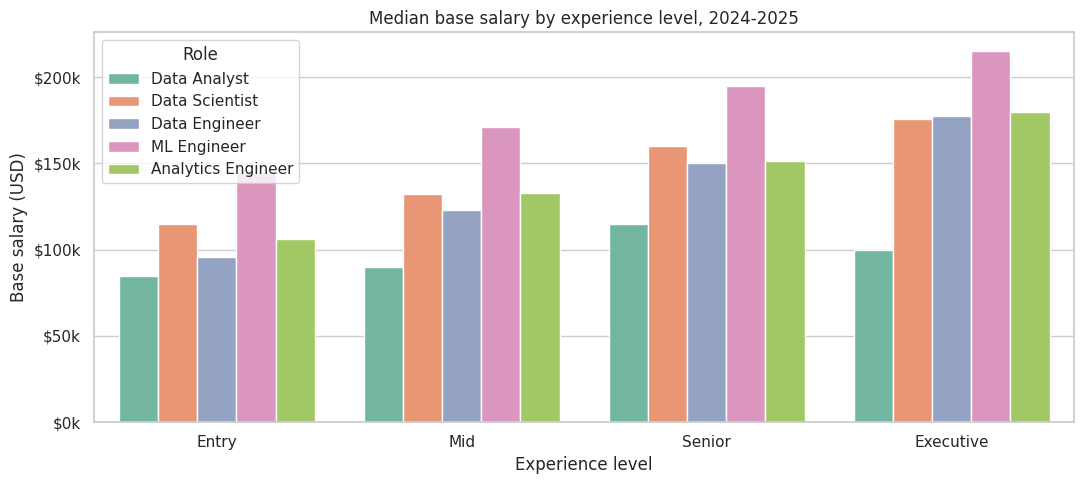

In [5]:
EXP_ORDER = ['Entry', 'Mid', 'Senior', 'Executive']
agg = (recent.groupby(['experience', 'role'], observed=True)['salary_in_usd']
             .median().reset_index())
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(agg, x='experience', y='salary_in_usd', hue='role',
            order=EXP_ORDER, hue_order=ROLES, palette=PALETTE, ax=ax)
ax.set_title('Median base salary by experience level, 2024-2025')
ax.set_xlabel('Experience level'); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role'); plt.tight_layout()

## 5. Remote-work share over time

Share of postings per role tagged fully remote (`remote_ratio == 100`).

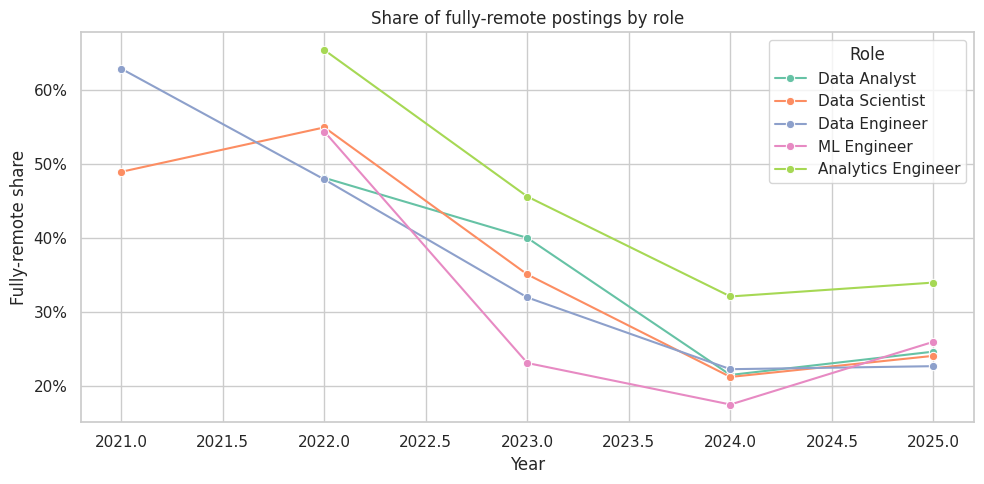

In [6]:
rem = (df.assign(fully_remote=(df['remote_ratio'] == 100).astype(int))
         .groupby(['year', 'role'])
         .agg(fully_remote_share=('fully_remote', 'mean'), n=('fully_remote', 'size'))
         .reset_index().query('n >= 30'))
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(rem, x='year', y='fully_remote_share', hue='role',
             hue_order=ROLES, palette=PALETTE, marker='o', ax=ax)
ax.set_title('Share of fully-remote postings by role')
ax.set_xlabel('Year'); ax.set_ylabel('Fully-remote share')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.legend(title='Role', loc='upper right'); plt.tight_layout()

## 6. International comparison (2024-2025)

Median base salary for each role across the top-6 employee-residence countries. Country/role cells with fewer than 30 postings are dropped.

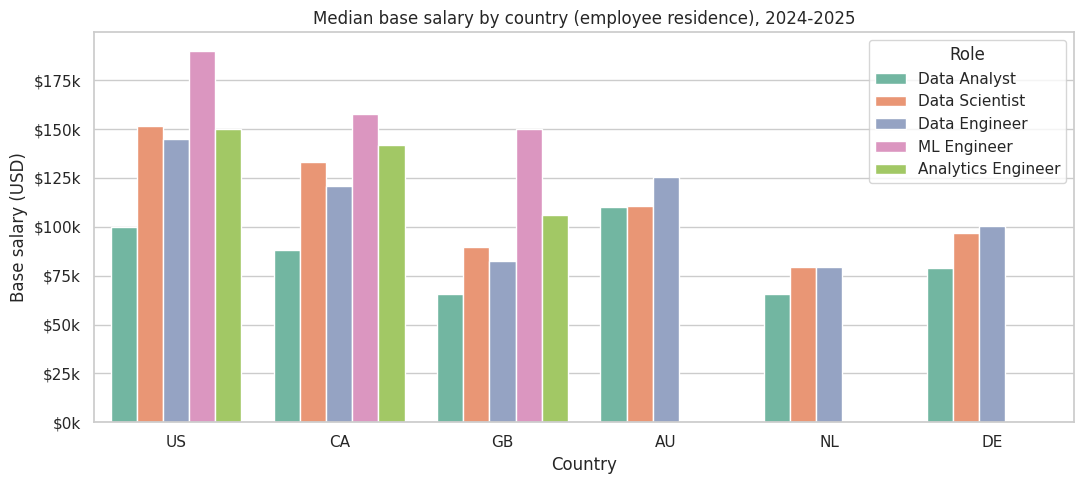

In [7]:
top_countries = recent['employee_residence'].value_counts().head(6).index.tolist()
geo = (recent[recent['employee_residence'].isin(top_countries)]
         .groupby(['employee_residence', 'role'])
         .agg(median_usd=('salary_in_usd', 'median'), n=('salary_in_usd', 'size'))
         .reset_index().query('n >= 30'))
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(geo, x='employee_residence', y='median_usd', hue='role',
             order=top_countries, hue_order=ROLES, palette=PALETTE, ax=ax)
ax.set_title('Median base salary by country (employee residence), 2024-2025')
ax.set_xlabel('Country'); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role', loc='upper right'); plt.tight_layout()

## 7. Summary table (2024-2025)

In [8]:
summary = recent.groupby('role').agg(
    n=('salary_in_usd', 'size'),
    median_base=('salary_in_usd', 'median'),
    p25_base=('salary_in_usd', lambda s: s.quantile(0.25)),
    p75_base=('salary_in_usd', lambda s: s.quantile(0.75)),
    fully_remote_pct=('remote_ratio', lambda s: (s == 100).mean() * 100),
).reindex(ROLES).round(0).astype(int)
summary

,n,median_base,p25_base,p75_base,fully_remote_pct
role,,,,,
Data Analyst,11007,98000,75000,125600,23
Data Scientist,14755,150000,111987,187000,23
Data Engineer,12591,140000,108000,179200,22
ML Engineer,6904,188725,148000,237500,21
Analytics Engineer,1671,145000,118500,176000,33


## Refresh

The raw CSV is cached at `data/aijobs_net_raw.csv` (gitignored). To pull a fresh copy from the mirror:

```bash
rm data/aijobs_net_raw.csv && python3 aijobs_net.py
```

Then re-run this notebook.